In [1]:
import sys
import os
import gc
import pandas as pd
import joblib
import matplotlib.pyplot as plt

#sistemare il warning di LightGBM fa creare warning a tutti gli altri modelli addestrati senza
#feature name, quindi meglio ingorarli
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

/home/nikko/miniconda3/envs/comp_phys/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

In [2]:
# Load dataset
data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# -------- Color indexes ----------

# star["u_g"] = star["u"] - star["g"]
# star["g_r"] = star["g"] - star["r"]
# star["r_i"] = star["r"] - star["i"]
# star["i_z"] = star["i"] - star["z"]

# star.info()


First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

In [3]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


Outliers removed: 408 rows  (99,592 remain)
X_train shape: (59754, 9)
X_val shape: (19919, 9)
X_test shape: (19919, 9)


In [4]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)

print("DataLoaders created.")

DataLoaders created.


In [5]:
# Train and evaluate traditional ML models
models = sc.train_traditional(X_train, y_train, X_val, y_val)


Linear SVC trained.
  [Training] Acc=75.51%  P=0.74  R=0.66  F1=0.65
  [Validation] Acc=75.69%  P=0.74  R=0.67  F1=0.65
Decision Tree trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=83.29%  P=0.79  R=0.79  F1=0.79
Random Forest trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=88.76%  P=0.86  R=0.85  F1=0.85
CatBoost trained.
  [Training] Acc=92.00%  P=0.91  R=0.89  F1=0.90
  [Validation] Acc=88.75%  P=0.86  R=0.85  F1=0.85
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 59754, number of used features: 9
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 9 dense feature groups (0.68 MB) transferred to GPU in 0.001755 secs. 0 

In [6]:
import torch
torch.cuda.empty_cache()

if os.path.exists('trained_models/stacking_clf_NOsmote_NOz.pkl'):
    stacking_clf = joblib.load('trained_models/stacking_clf_NOsmoteNOz.pkl')
    print("Stacking Classifier caricato da disco")
else:
    stacking_clf = sc.train_stacking(X_train, y_train, X_val, y_val, n_jobs=2)
    os.makedirs('trained_models', exist_ok=True)
    joblib.dump(stacking_clf, 'trained_models/stacking_clf_NOsmoteNOz.pkl')
    print("Stacking Classifier trained and saved")

Linear SVC trained.
Decision Tree trained.
Random Forest trained.
CatBoost trained.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002007 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 59754, number of used features: 9
[LightGBM] [Info] Start training from score -0.520901
[LightGBM] [Info] Start training from score -1.660490
[LightGBM] [Info] Start training from score -1.532621
LightGBM trained.
starting training...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000807 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 59754, number of used features: 9
[LightGBM] [Info] Start training from score -0.520901
[LightGBM] [Info] Sta

In [7]:
if os.path.exists('trained_models/voting_clf_NOsmoteNOz.pkl'):
    voting_clf = joblib.load('trained_models/voting_clf_NOsmoteNOz.pkl')
    print("Voting Classifier caricato da disco")
else:
    voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models)
    os.makedirs('trained_models', exist_ok=True)
    joblib.dump(voting_clf, 'trained_models/voting_clf_NOsmoteNOz.pkl')
    print("Voting Classifier trained and saved")

# for m in (train_m, val_m):
#         print(
#             f"  [{m['dataset']}] Acc={m['accuracy']:.2f}%  "
#             f"P={m['precision']:.2f}  R={m['recall']:.2f}  F1={m['f1']:.2f}"
#         )

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 59754, number of used features: 9
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 9 dense feature groups (0.68 MB) transferred to GPU in 0.001675 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -0.520901
[LightGBM] [Info] Start training from score -1.660490
[LightGBM] [Info] Start training from score -1.532621
Voting Classifier trained.
  [Training] Acc=94.38%  P=0.94  R=0.92  F1=0.93
  [Validation] Acc=88.80%  P=0.86  R=0.84  F1=0.85
Voting Classifier trained and saved


NameError: name 'train_m' is not defined

In [8]:
import torch
from stellar_classification.models.network import SimpleNN

input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

if os.path.exists('trained_models/nn_model_NOsmoteNOz.pth'):
    nn_model = SimpleNN(input_size, num_classes)
    nn_model.load_state_dict(torch.load('trained_models/nn_model_NOsmote.pth'))
    nn_model.eval()
    print("NN caricata da disco")
else:
    nn_model = sc.train_neural( 
        train_loader=train_loader,
        val_loader=val_loader,
        input_size=input_size,
        num_classes=num_classes,
        num_epochs=10,
        lr=0.001
    )
    torch.save(nn_model.state_dict(), 'trained_models/nn_model_NOsmote.pth')
    print("NN trained nad saved")

Epoch  1/10  loss=0.6003  val_acc=81.09%
Epoch  2/10  loss=0.4905  val_acc=83.03%
Epoch  3/10  loss=0.4548  val_acc=84.30%
Epoch  4/10  loss=0.4375  val_acc=84.83%
Epoch  5/10  loss=0.4265  val_acc=85.57%
Epoch  6/10  loss=0.4178  val_acc=85.96%
Epoch  7/10  loss=0.4108  val_acc=86.16%
Epoch  8/10  loss=0.4059  val_acc=86.20%
Epoch  9/10  loss=0.4009  val_acc=86.46%
Epoch 10/10  loss=0.3966  val_acc=86.56%
NN trained nad saved


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

y_test_pred_voting = voting_clf.predict(X_test)
voting_metrics = sc.evaluate_test_set(y_test, y_test_pred_voting, "Voting Classifier")
sc.print_metrics(voting_metrics)

y_test_pred_stacking = stacking_clf.predict(X_test)
stacking_metrics = sc.evaluate_test_set(y_test, y_test_pred_stacking, "Stacking Classifier")
sc.print_metrics(stacking_metrics)
    
nn_metrics = sc.evaluate_neural(test_loader, nn_model, device, "Neural Network")
sc.print_metrics(nn_metrics)



Voting Classifier:
  Accuracy  : 88.63%
  Precision: 0.8605
  Recall   : 0.8419
  F1       : 0.8492
  Confusion Matrix:
[[11341   304   186]
 [  351  3140   295]
 [  599   529  3174]]

Stacking Classifier:
  Accuracy  : 89.01%
  Precision: 0.8601
  Recall   : 0.8502
  F1       : 0.8548
  Confusion Matrix:
[[11279   287   265]
 [  329  3080   377]
 [  484   447  3371]]

Neural Network:
  Accuracy  : 86.36%
  Precision: 0.8317
  Recall   : 0.8140
  F1       : 0.8212
  Confusion Matrix:
[[11169   335   327]
 [  425  3013   348]
 [  721   561  3020]]


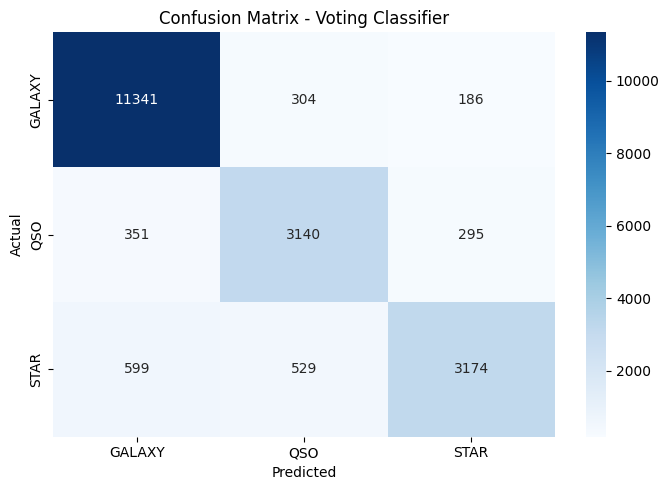

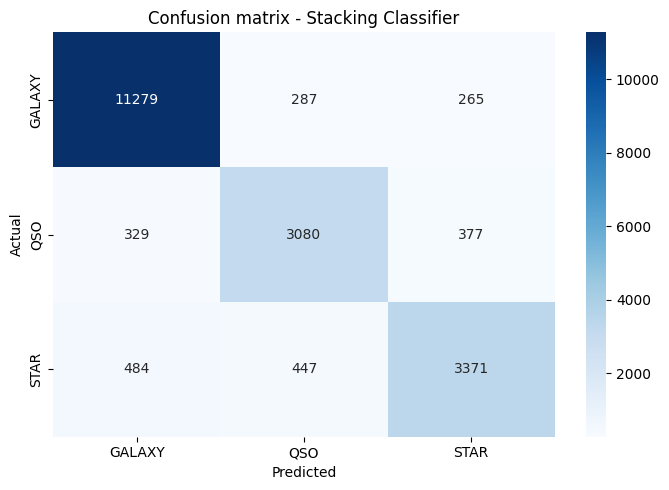

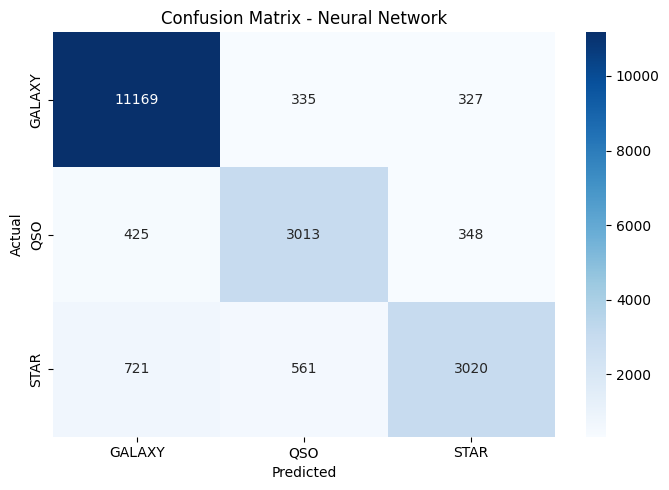

In [10]:
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(voting_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Voting Classifier')
sc.plot_confusion_matrix(stacking_metrics['confusion_matrix'], class_names=class_names, title='Confusion matrix - Stacking Classifier')
sc.plot_confusion_matrix(nn_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Neural Network')


1 batch shape: 4000
2 batch shape: 4000
3 batch shape: 4000
4 batch shape: 4000
5 batch shape: 3919
[array([0.032  , 0.0111 , 0.0894 , 0.2821 , 0.1812 , 0.08785, 0.25765,
       0.05605, 0.01535]), array([0.02805, 0.0096 , 0.08905, 0.26735, 0.1837 , 0.08555, 0.24785,
       0.06205, 0.0145 ]), array([0.03145, 0.01025, 0.0895 , 0.27545, 0.19415, 0.09485, 0.2567 ,
       0.0604 , 0.01865]), array([0.0261 , 0.0114 , 0.09175, 0.27265, 0.1874 , 0.08945, 0.25605,
       0.0631 , 0.0149 ]), array([0.02357744, 0.01183976, 0.08532789, 0.26067874, 0.18193417,
       0.07797908, 0.24557285, 0.06516969, 0.01791273])]


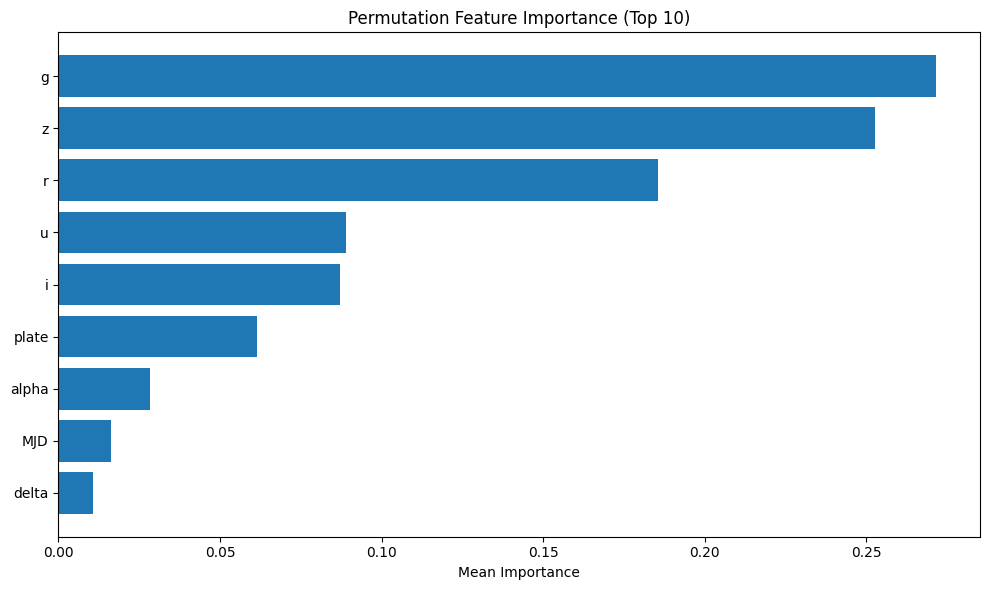

Feature Importance Scores:
g: 0.2716
z: 0.2528
r: 0.1857
u: 0.0890
i: 0.0871
plate: 0.0614
alpha: 0.0282
MJD: 0.0163
delta: 0.0108
1 batch shape: 4000
2 batch shape: 4000
3 batch shape: 4000
4 batch shape: 4000
5 batch shape: 3919
[array([0.0386 , 0.0182 , 0.10005, 0.2615 , 0.21025, 0.0984 , 0.3208 ,
       0.07205, 0.0225 ]), array([0.03415, 0.01905, 0.10125, 0.24975, 0.203  , 0.0927 , 0.3038 ,
       0.07915, 0.0207 ]), array([0.0313 , 0.0186 , 0.09795, 0.2543 , 0.217  , 0.1029 , 0.31585,
       0.07745, 0.02305]), array([0.03735, 0.0202 , 0.10475, 0.26275, 0.2125 , 0.1037 , 0.31695,
       0.082  , 0.02895]), array([0.03189589, 0.0166369 , 0.10232202, 0.24536872, 0.20403164,
       0.08701199, 0.306864  , 0.08221485, 0.02388364])]


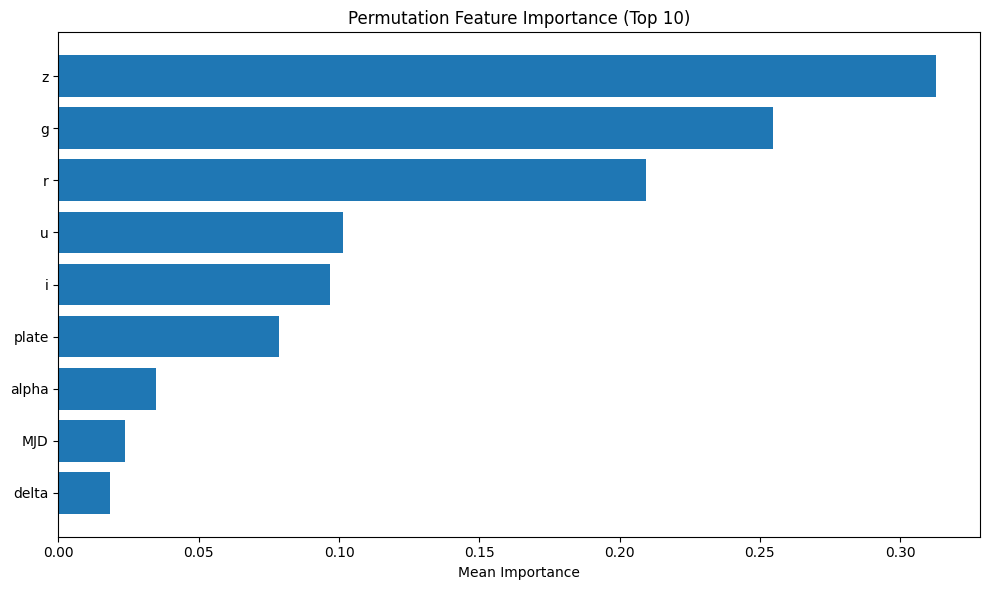

Feature Importance Scores:
z: 0.3129
g: 0.2547
r: 0.2094
u: 0.1013
i: 0.0969
plate: 0.0786
alpha: 0.0347
MJD: 0.0238
delta: 0.0185


In [11]:
imp = sc.compute_permutation_importance(voting_clf, X_test, y_test, feature_names=feature_names, n_jobs=6)
sc.plot_permutation_importance(imp, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}")

imp = sc.compute_permutation_importance(stacking_clf, X_test, y_test, feature_names=feature_names, n_jobs=6)
sc.plot_permutation_importance(imp, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}") 



In [ ]:
def classify(index):

    res = stacking_clf.predict(star[index])
    classes = {0:'Galasy', 1:'Quasar', 2:'Star'}
    return classes[res[0]]



In [ ]:
classify(7)

In [ ]:
print(star.type())